# 2 · Entrenamiento y evaluación

> **Tipo de ML:** `supervisado`  · Modelo activo: `RandomForest`


## 0. Entorno


In [1]:
# Verificar que el entorno está activo
import sys
print(f'Python: {sys.version}')
import xgboost; print(f'XGBoost: {xgboost.__version__}')



Python: 3.13.5 (main, May  5 2026, 21:05:52) [GCC 14.2.0]
XGBoost: 3.3.0


## 1. Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from climasafeai.utils.paths import (
    PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR,
)


from climasafeai.models.train_model import train_models, load_models
from climasafeai.models.predict_model import evaluate_models, predict_new, DECISION_THRESHOLD
from climasafeai.visualization.visualize import plot_feature_importance


## 2. Cargar datos procesados


In [3]:
# ── Carga de datos procesados ───────────────────────────────────────────────
# Si el pipeline aún no se ha ejecutado, corre primero: make data && make features
try:
    
    X_train = pd.read_csv(PROCESSED_DATA_DIR / 'X_train_calor.csv')
    X_test  = pd.read_csv(PROCESSED_DATA_DIR / 'X_test_calor.csv')
    y_train = pd.read_csv(PROCESSED_DATA_DIR / 'y_train_calor.csv').squeeze()
    y_test  = pd.read_csv(PROCESSED_DATA_DIR / 'y_test_calor.csv').squeeze()
    print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
    print(f'Clases: {sorted(y_train.unique().tolist())}')
    print(f'Balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')
    
except FileNotFoundError as _e:
    raise FileNotFoundError(
        f"Datos no encontrados: {_e}\n"
        "Ejecuta primero: make data && make features\n"
        "O desde este notebook: !make data features"
    ) from _e


Train: (137916, 7)  |  Test: (34479, 7)
Clases: [0, 1, 2]
Balance (train): {0: 0.895, 1: 0.055, 2: 0.05}


## 3. Configuración


Modelo activo: `RandomForest`. Cambia `model_type` en json y regenera para entrenar otro.



In [4]:

# Configuración: model_type activo = 'RandomForest'
# tune_knn=True  → busca el k óptimo para KNN (lento en datasets grandes)
# cv_evaluate=True → muestra F1 5-fold de cada modelo antes de guardar
TUNE_KNN    = True
CV_EVALUATE = True


## 4. Entrenar


In [5]:
# ejecutar make mlflow
models = train_models(X_train, y_train, tune_knn=TUNE_KNN, cv_evaluate=CV_EVALUATE)

--> Entrenando modelos de clasificacion...
    [KNN] buscando mejor k en [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]...
    [KNN] mejor k = 7 (F1_weighted CV = 0.869)
    AVISO: no se pudo conectar al tracking server de MLflow (API request to http://localhost:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=climasafeai (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused"))).
    Usando tracking local (sqlite:////home/cacelas/Documentos/anfaia/ClimaSafeAI/mlflow.db) en su lugar.


2026/07/07 16:02:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 16:02:13 INFO mlflow.store.db.utils: Updating database tables
2026/07/07 16:03:09 INFO mlflow.tracking.fluent: Experiment with name 'climasafeai' does not exist. Creating a new experiment.


    [RandomForest] entrenando...
      F1_weighted 5-fold CV: 0.796


2026/07/07 16:03:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      Guardado → RandomForest.joblib


...

    [KNN] entrenando...


2026/07/07 16:04:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


      F1_weighted 5-fold CV: 0.869
      Guardado → KNN.joblib


2026/07/07 16:04:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/07 16:04:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'climasafeai_KNN'.
Created version '1' of model 'climasafeai_KNN'.


--> 3 modelos guardados en /home/cacelas/Documentos/anfaia/ClimaSafeAI/models


## 5. Evaluar


In [6]:

threshold  = DECISION_THRESHOLD   # ajustar si clases muy desbalanceadas
df_results = evaluate_models(
    models, X_train, y_train, X_test, y_test, threshold=threshold
)
df_results.sort_values('F1_test', ascending=False)



  Evaluación — clasificacion (umbral=0.5)

--- RandomForest ---
  Accuracy  → train: 0.752 | test: 0.731
  F1 (w)    → train: 0.807  | test: 0.794
  Precision → 0.903  | Recall → 0.731

              precision    recall  f1-score   support

           0       0.99      0.75      0.85     30867
           1       0.15      0.51      0.23      1894
           2       0.23      0.57      0.33      1718

    accuracy                           0.73     34479
   macro avg       0.45      0.61      0.47     34479
weighted avg       0.90      0.73      0.79     34479

    cm_RandomForest.png guardado

--- XGBoost ---
  Accuracy  → train: 0.905 | test: 0.900
  F1 (w)    → train: 0.874  | test: 0.868
  Precision → 0.859  | Recall → 0.900

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     30867
           1       0.37      0.04      0.07      1894
           2       0.46      0.19      0.26      1718

    accuracy                           0.9

,Modelo,Acc_train,Acc_test,F1_train,F1_test,Prec_test,Rec_test
2,KNN,1.0000,0.8904,1.0000,0.8698,0.8570,0.8904
1,XGBoost,0.9045,0.8996,0.8739,0.8676,0.8593,0.8996
0,RandomForest,0.7519,0.7311,0.8067,0.7936,0.9026,0.7311


## 6. Importancia de variables


    feature_importance.png guardado


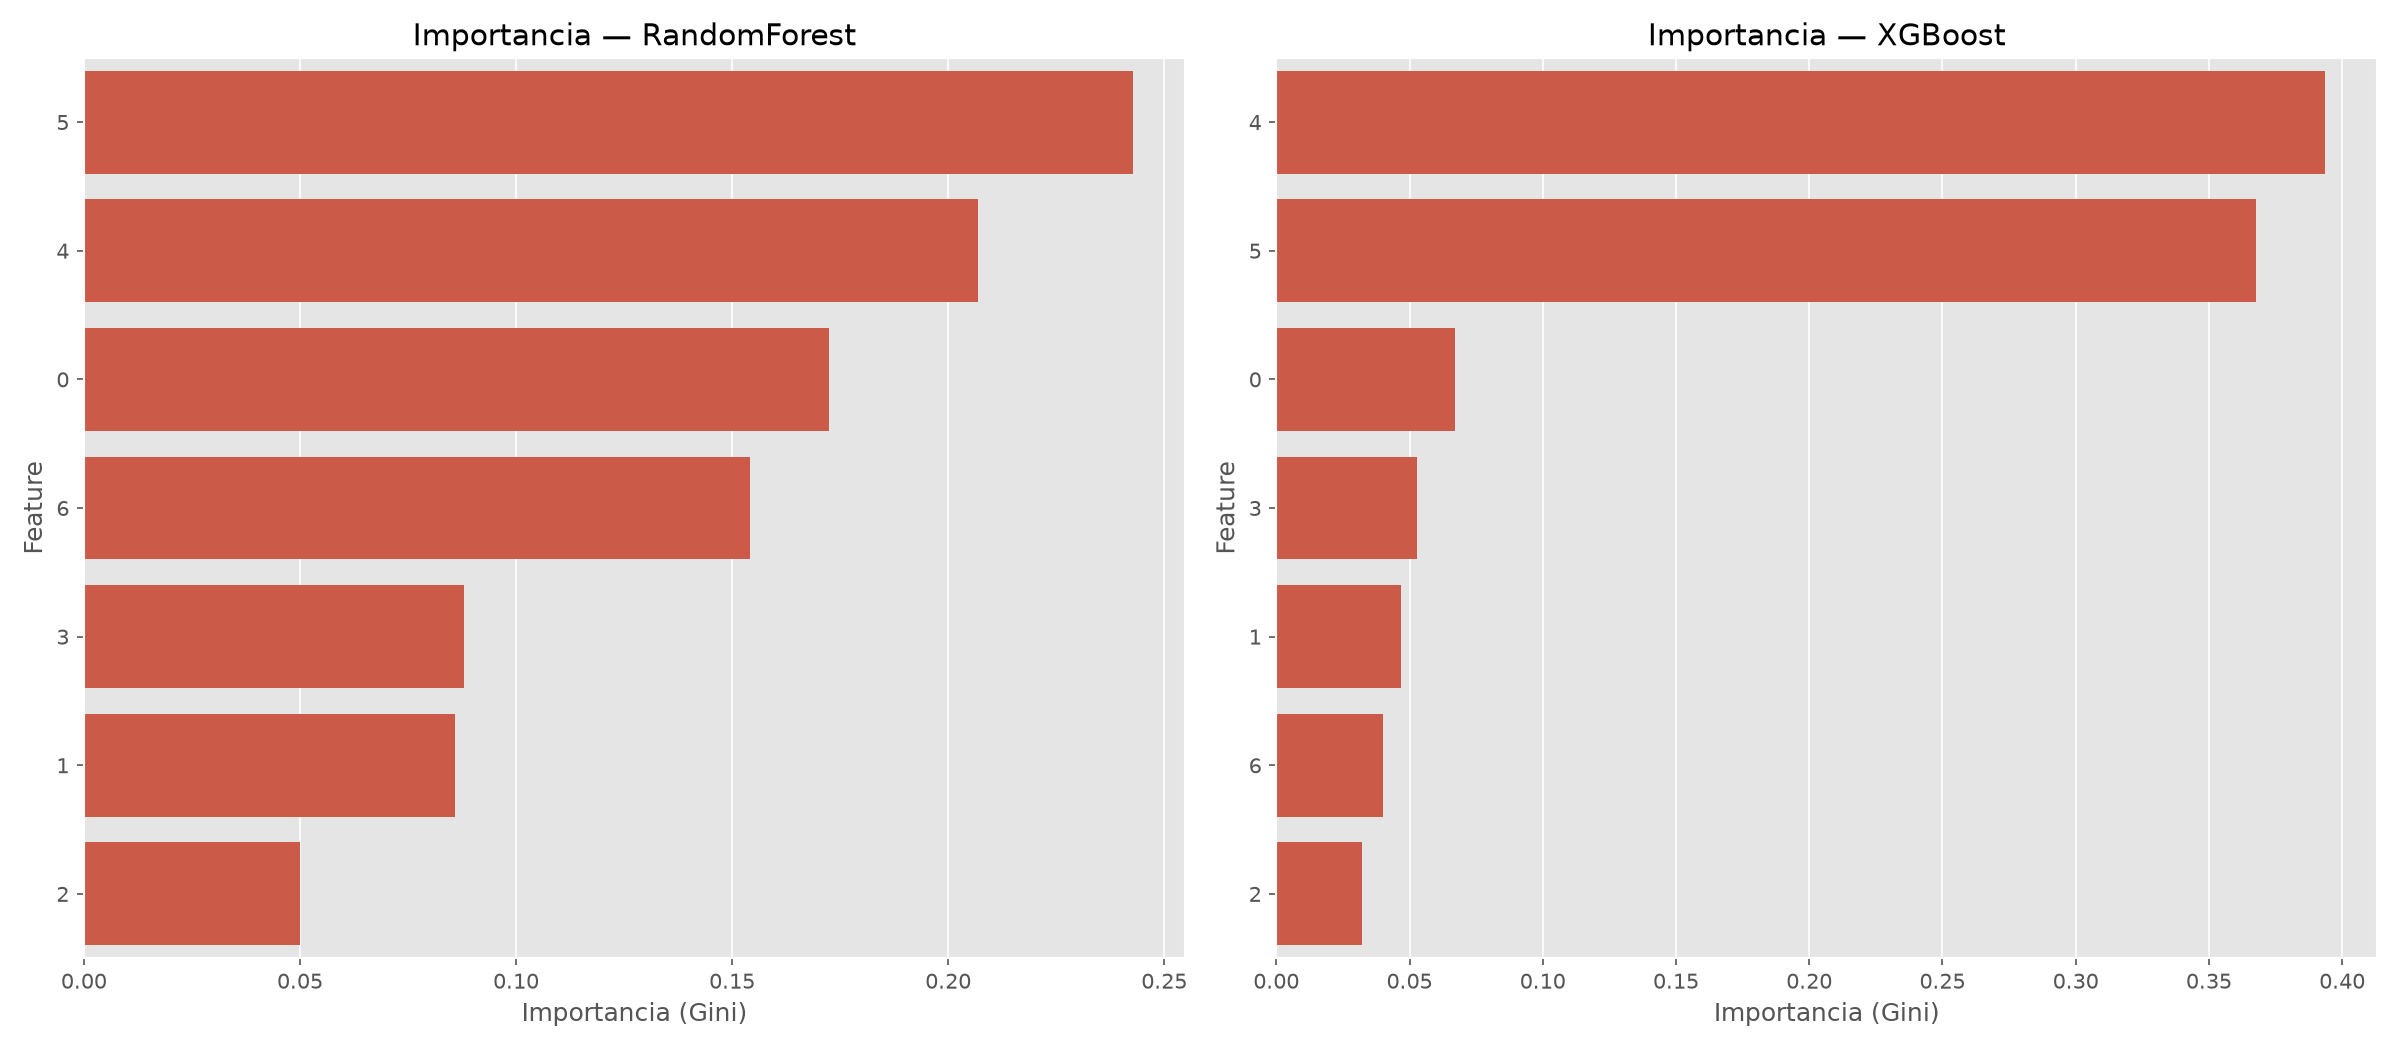

In [7]:

feature_names = X_train.columns.tolist()
plot_feature_importance(models, feature_names)
from IPython.display import Image
Image(FIGURES_DIR / 'feature_importance.png')


## 7. Predicción sobre nuevos datos


In [8]:

best_name  = df_results.sort_values('F1_test', ascending=False).iloc[0]['Modelo']
best_model = models[best_name]
print(f'Mejor modelo: {best_name}')

# Predecir sobre nuevos datos:
# from climasafeai.features.build_features import process_input
# X_new   = process_input(df_nuevos)
# preds, probs = predict_new(best_model, X_new, threshold=threshold)


Mejor modelo: KNN


## 8. Profiling (opcional)

Si el entrenamiento es lento, identifica dónde se va el tiempo:

```bash
make profile
snakeviz reports/profile.prof
```
